In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Network

## Template 04
### Flowers Dataset

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [2]:
###-----------------
### Import libraries
###-----------------

from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib
import cv2
from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score  # Import function to calculate various metric

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms, datasets
from torchvision.transforms import v2
from torchsummary import summary

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.preprocessing import StandardScaler, LabelEncoder  # Import for standardizing features (zero mean, unit variance)

# from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix, fn_plot_label# Custom utility

import tensorflow as tf

ModuleNotFoundError: No module named 'albumentations'

In [3]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'
subDir = 'flower_photos'
valDir='valid_flowers'
altName='flower_augmnt'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # setting for Tensorflow as well
torch.manual_seed(RANDOM_STATE)


EPOCHS = 200 # number of cycles to run
NO_SAVE_EPOCHS=20
BATCH_SIZE = 16 # inline of Training Rows being 60000
TRAIN_SIZE=184*BATCH_SIZE

ALPHA = 0.001
WEIGHT_DECAY=le-5
EPSILON=1e-8

PATIENCE = 20
MIN_DELTA=1e-5
LR_PATIENCE = 5
LR_FACTOR = 0.1
MIN_LR=1e-6

IMG_HEIGHT=190
IMG_WIDTH=190


# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,10),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## Basic Hygiene

In [4]:
physical_devices = tf.config.list_physical_devices('GPU') 

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [5]:
print (physical_devices)

[]


In [6]:
import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(origin=dataset_url,
                                   fname='flower_photos',
                                   untar=True)
data_dir = pathlib.Path(data_dir)/subDir


# data_dir ='./flower_photos/'
data_dir

WindowsPath('C:/Users/PGCP-AI/.keras/datasets/flower_photos/flower_photos')

In [7]:
# List only directories
directories = [item for item in data_dir.iterdir() if item.is_dir()]
directories

[WindowsPath('C:/Users/PGCP-AI/.keras/datasets/flower_photos/flower_photos/daisy'),
 WindowsPath('C:/Users/PGCP-AI/.keras/datasets/flower_photos/flower_photos/dandelion'),
 WindowsPath('C:/Users/PGCP-AI/.keras/datasets/flower_photos/flower_photos/roses'),
 WindowsPath('C:/Users/PGCP-AI/.keras/datasets/flower_photos/flower_photos/sunflowers'),
 WindowsPath('C:/Users/PGCP-AI/.keras/datasets/flower_photos/flower_photos/tulips')]

In [8]:
# create training data
train_ds =tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, # path the the data directory
    validation_split=TEST_SIZE, # what ratio of validation data
    subset='training', # purpose
    seed=RANDOM_STATE, 
    image_size=[IMG_HEIGHT, IMG_WIDTH], ## @@@ WHAT!
    batch_size=BATCH_SIZE
)
# test data
test_ds =tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, # path the the data directory
    validation_split=TEST_SIZE, # what ratio of validation data
    subset='validation', # purpose
    seed=RANDOM_STATE, 
    image_size=[IMG_HEIGHT, IMG_WIDTH], ## @@@ WHAT!
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [9]:
# is it picking class names
class_names = train_ds.class_names
class_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

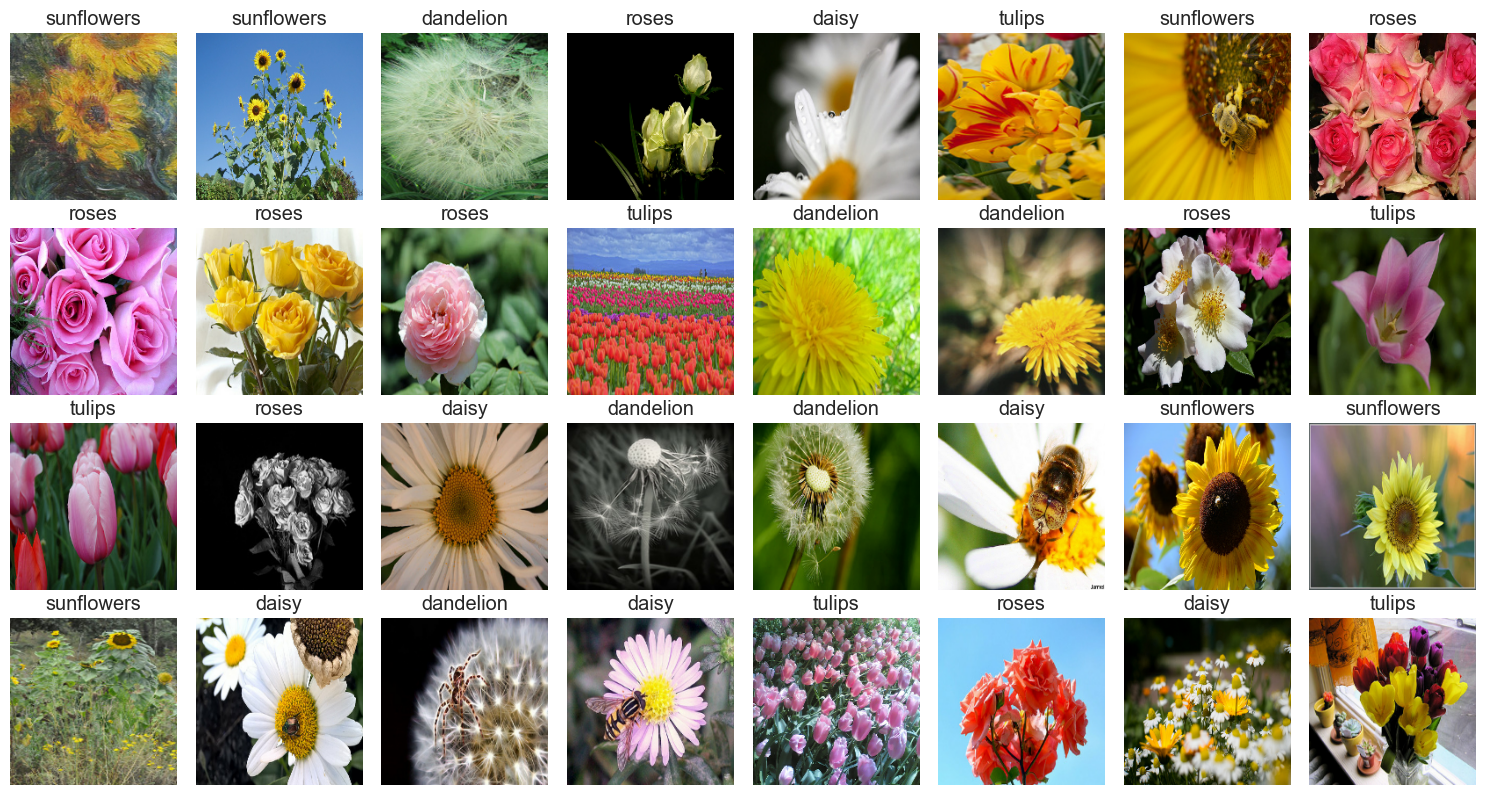

In [10]:
plt.figure(figsize=(15,8))

for images, labels in train_ds.take(1):
    for i in range (BATCH_SIZE):
        plt.subplot(int(BATCH_SIZE/8), 8, i +1)
        plt.grid(False)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
plt.show()

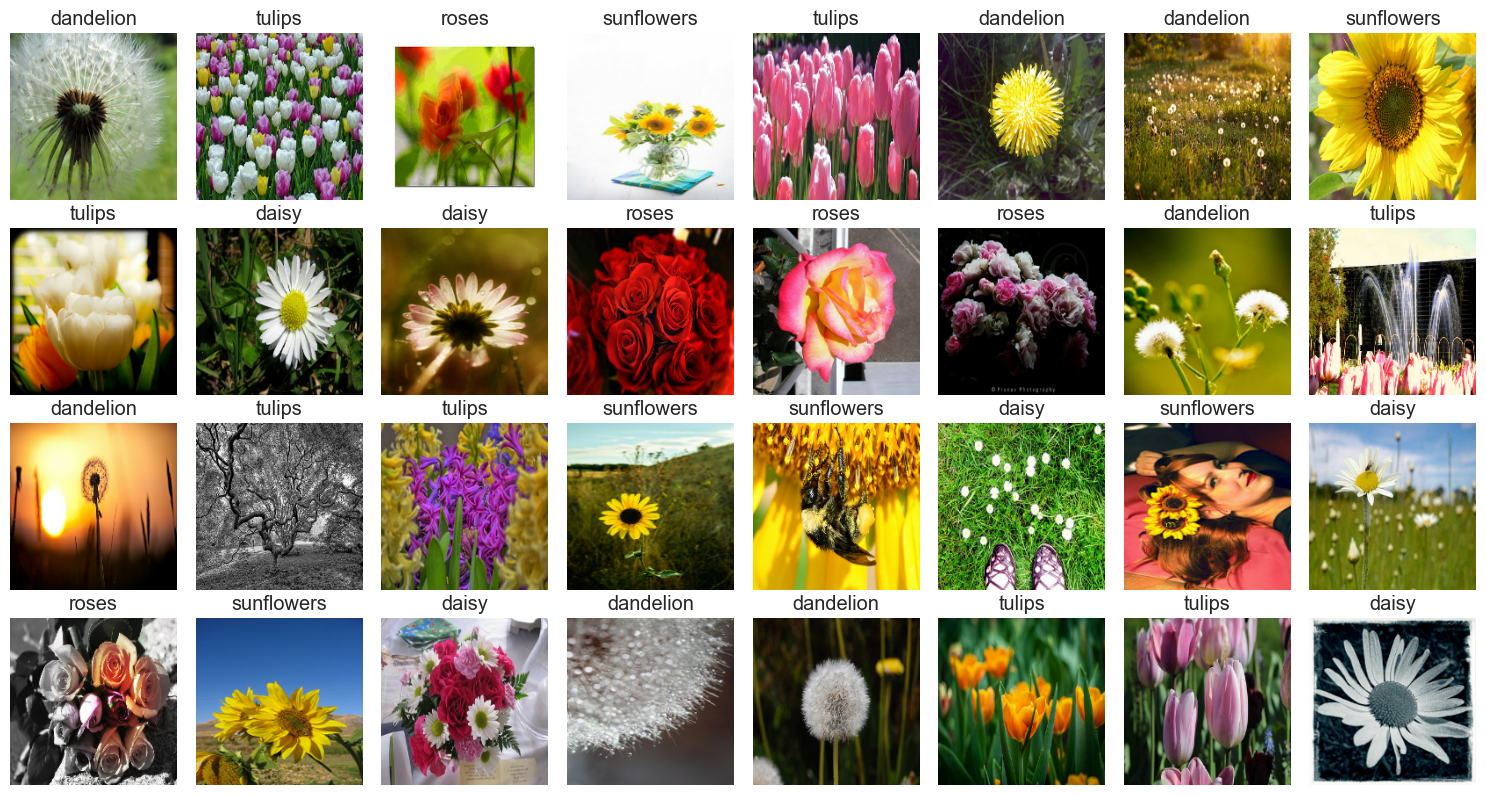

In [11]:
plt.figure(figsize=(15,8))

for images, labels in test_ds.take(1): # get me one batch
    
    for i in range (BATCH_SIZE): # loop over batch
        
        plt.subplot(int(BATCH_SIZE/8), 8, i +1) # access the axis
        
        plt.grid(False) # no to grid
        
        plt.imshow(images[i].numpy().astype('uint8')) # show image convert to numpy and int
        
        plt.title(class_names[labels[i]])
        
        plt.axis('off')
    
    plt.tight_layout()

plt.show()

In [12]:
# fn_plot_label(train_ds, test_ds)

In [13]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
input_shape

(190, 190, 3)

In [14]:
zoom_layer = tf.keras.layers.RandomZoom(height_factor=(-0.2, 0.2), width_factor=(-0.2, 0.2), fill_mode='reflect')

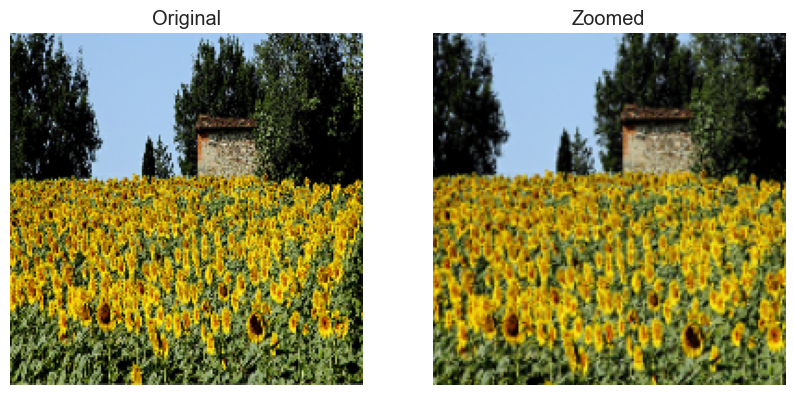

In [15]:
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(images[0].numpy().astype('uint8'))
    plt.title('Original')
    plt.axis('off')
    
    # Zoomed Image
    out_image = zoom_layer(images)
    plt.subplot(1, 2, 2)
    plt.imshow(out_image[0].numpy().astype('uint8'))
    plt.title('Zoomed')
    plt.axis('off')

plt.show()
    


In [16]:
#is it picking class names
class_name=train_ds.class_names
class_name

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [17]:
num_classes=len(class_name)

In [18]:
train_ds=train_ds.cache()
train_ds=train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [19]:
# Create an augmentation pipeline layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1), # Adds lighting variations
])

In [20]:
def build_model(input_shape, num_classes):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=input_shape))
    model.add(data_augmentation)
    model.add(tf.keras.layers.Rescaling(1./255))
    
    # Block 1 - Notice model.add() around BatchNormalization
    model.add(tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(tf.keras.layers.BatchNormalization()) 
    model.add(tf.keras.layers.MaxPooling2D())
    
    # Block 2
    model.add(tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling2D())
    
    # Block 3
    model.add(tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling2D())
    model.add(tf.keras.layers.Dropout(0.3))
    
    # Flatten & Deeper Dense Layers
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dropout(0.5))
    
    model.add(tf.keras.layers.Dense(num_classes))
    return model

In [21]:
# 1. Instantiate the model first!
model = build_model(input_shape=input_shape, num_classes=num_classes)

# 2. Define the learning rate reduction callback
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=FACTOR_LR,      # Drop LR by half (0.5)
    patience=LR_PATIENCE,  # Wait 10 epochs before dropping
    verbose=1,
    min_lr=1e-6
)

# 3. Compile as normal
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

# 4. Fit with the callback included
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=test_ds,
    callbacks=[lr_callback] 
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 719ms/step - accuracy: 0.3920 - loss: 10.4903 - val_accuracy: 0.2384 - val_loss: 33.5555 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 627ms/step - accuracy: 0.3634 - loss: 3.0026 - val_accuracy: 0.2384 - val_loss: 21.9533 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 627ms/step - accuracy: 0.3992 - loss: 2.7518 - val_accuracy: 0.2439 - val_loss: 8.0850 - learning_rate: 0.0010
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 632ms/step - accuracy: 0.4322 - loss: 2.6377 - val_accuracy: 0.3079 - val_loss: 4.5424 - learning_rate: 0.0010
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 629ms/step - accuracy: 0.4295 - loss: 2.5593 - val_accuracy: 0.4019 - val_loss: 2.7668 - learning_rate: 0.0010
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 629ms/step - accuracy: 0.4257 - loss: 2.4317 - val_accuracy: 0.4619 - val_loss: 2.3443 - learning_rate: 0.0010
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 631ms/step - accuracy: 0.4292 - loss:

In [22]:
hist_df = pd.DataFrame(history.history)
hist_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.392030,10.490291,0.238420,33.555527,0.001
1,0.363420,3.002579,0.238420,21.953300,0.001
2,0.399183,2.751811,0.243869,8.084990,0.001
3,0.432221,2.637715,0.307902,4.542427,0.001
4,0.429496,2.559333,0.401907,2.766763,0.001


In [23]:


###-----------------------------------------------------------
### Function to plot Loss Curve using Tensorflow history object
###------------------------------------------------------------

###-----------------------------------------------------------
### Function to plot Loss Curve using Tensorflow history object
###------------------------------------------------------------

def fn_plot_tf_hist(hist_df):
    
    '''
    Args:
        hist_df: a DataFrame with column names accuracy,loss	val_accuracy	val_loss
    '''
        
    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch 
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm
    
    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]
    
    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = "Loss: \n  train: {:6.4f}\n   test: {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot
    
    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)
    
    # calculate offset for arrow
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0
    
    best_idx = best.index.to_numpy()[0]  # Extract first (and only) element as scalar
    best_value = best[y4].to_numpy()[0]   # Extract scalar value
    
    # Mark arrow at lowest
    ax.annotate(f'Min: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value + offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Loss Curve')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left
    
    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)
    
    # little beautification
    txtFmt = "Accuracy: \n  train: {:6.4f}\n  test:  {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    best_value = best[y3].to_numpy()[0]   # Extract scalar value
    # Mark arrow at lowest
    ax.annotate(f'Best: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value-offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.set_title('Accuracy Curve')
    ax.grid(True)
    ax.legend(loc = 'lower left')
    
    plt.tight_layout()
    

    

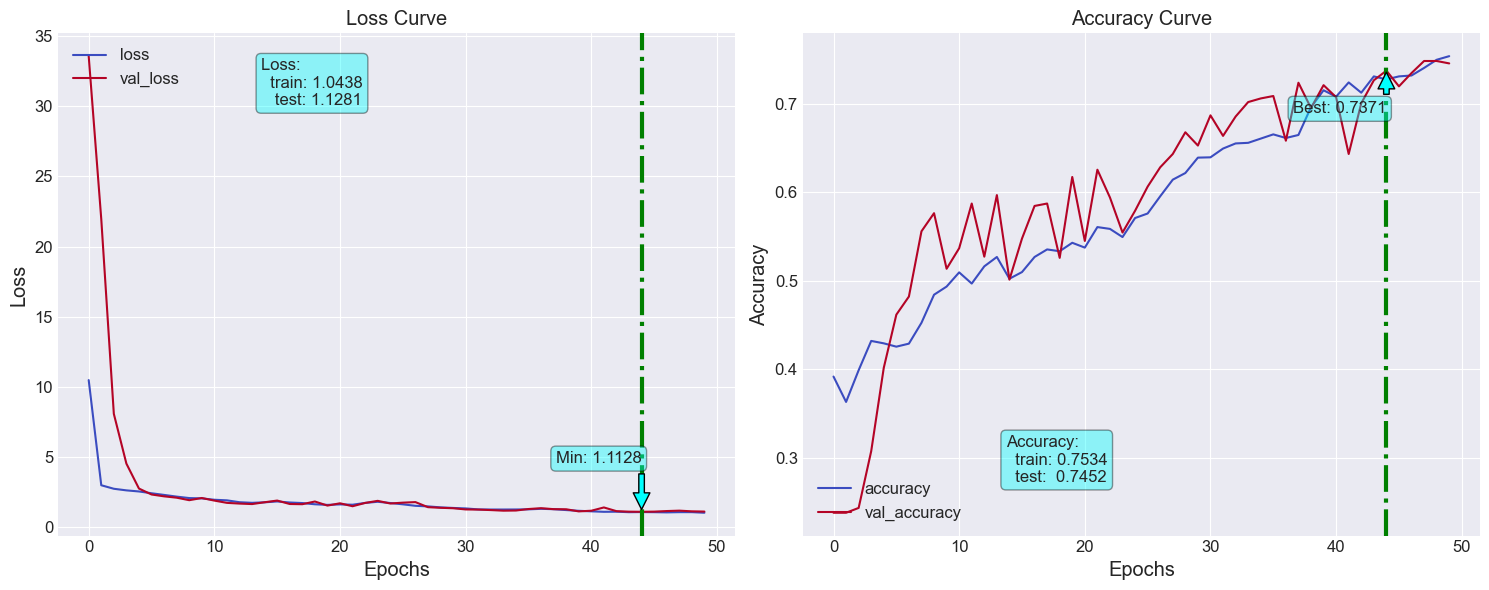

In [24]:
fn_plot_tf_hist(hist_df)